<a href="https://colab.research.google.com/github/mpatel5/CSCI_221_Final_Project/blob/main/Part2_KMeans_MusicSelections_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2: K-Means Clustering - Music Selections Dataset

# Import libraries

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

# Load dataset

In [215]:
df = pd.read_csv("music_selections.csv")

# Preview the dataset

In [216]:
print(df.head())
print(df.info())

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

In [217]:
print("Summary Statistics:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nShape of Data:")
print(df.shape)

Summary Statistics:
       track_popularity  danceability        energy           key  \
count      32833.000000  32833.000000  32833.000000  32833.000000   
mean          42.477081      0.654850      0.698619      5.374471   
std           24.984074      0.145085      0.180910      3.611657   
min            0.000000      0.000000      0.000175      0.000000   
25%           24.000000      0.563000      0.581000      2.000000   
50%           45.000000      0.672000      0.721000      6.000000   
75%           62.000000      0.761000      0.840000      9.000000   
max          100.000000      0.983000      1.000000     11.000000   

           loudness          mode   speechiness  acousticness  \
count  32833.000000  32833.000000  32833.000000  32833.000000   
mean      -6.719499      0.565711      0.107068      0.175334   
std        2.988436      0.495671      0.101314      0.219633   
min      -46.448000      0.000000      0.000000      0.000000   
25%       -8.171000      0.000000

# Display a visualization of the distribution of the data

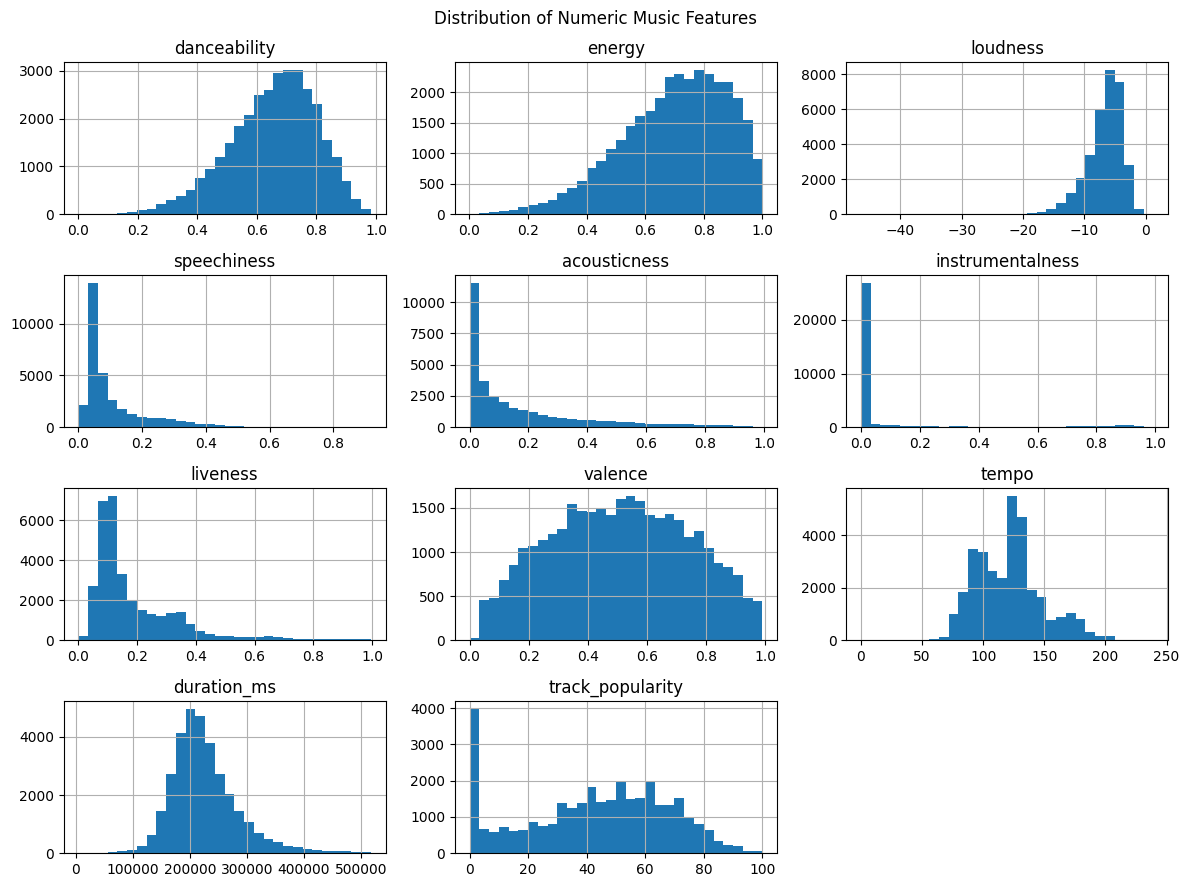

In [218]:
# Keep only continuous audio features for clustering
# Non-numeric columns and integer-encoded categoricals (key, mode) are excluded
# because K-Means uses distance calculations and they would produce misleading results
df_numeric = df[["danceability", "energy", "loudness", "speechiness",
                  "acousticness", "instrumentalness", "liveness",
                  "valence", "tempo", "duration_ms", "track_popularity"]]

# Display histograms for the numeric variables
df_numeric.hist(figsize=(12, 9), bins=30)
plt.suptitle("Distribution of Numeric Music Features")
plt.tight_layout()
plt.show()

# Clean the data

In [219]:
# Select only numeric columns for clustering
df_numeric = df[["danceability", "energy", "loudness", "speechiness",
                 "acousticness", "instrumentalness", "liveness",
                 "valence", "tempo", "duration_ms", "track_popularity"]]

# Check for missing values
print("Missing Values:")
print(df_numeric.isnull().sum())

# Fill missing numeric values with the column median
# Median is used because audio features like instrumentalness and speechiness
# are often skewed, making the median more robust than the mean
#df_numeric = df_numeric.fillna(df_numeric.median())

# No missing values were found, so no imputation or removal was necessary.

Missing Values:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
track_popularity    0
dtype: int64


In [220]:
# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if any
#df = df.drop_duplicates()

# Re-select numeric columns after removing duplicates
#df_numeric = df[["danceability", "energy", "loudness", "speechiness",
#                 "acousticness", "instrumentalness", "liveness",
#                 "valence", "tempo", "duration_ms", "track_popularity"]]

#df_numeric = df_numeric.fillna(df_numeric.median())

# No duplicate rows were found, so no removal was necessary.


Duplicate Rows: 0


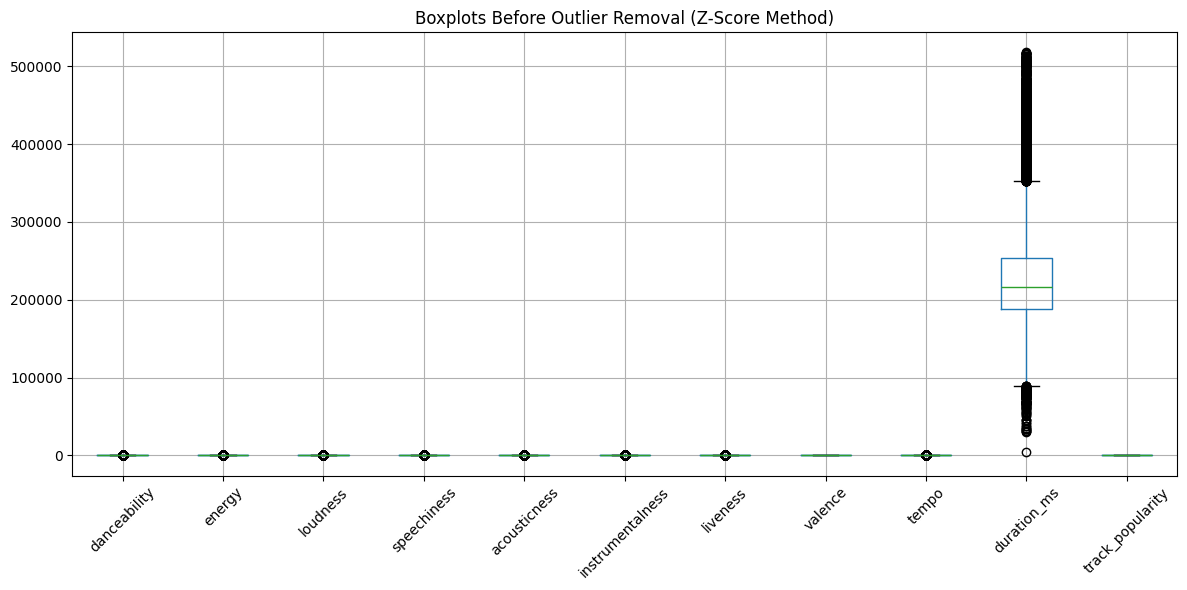


Outlier Counts by Column:
danceability: 123 outliers
energy: 166 outliers
loudness: 368 outliers
speechiness: 612 outliers
acousticness: 657 outliers
instrumentalness: 1692 outliers
liveness: 831 outliers
valence: 0 outliers
tempo: 119 outliers
duration_ms: 527 outliers
track_popularity: 0 outliers

Original shape: (32833, 11)
After outlier removal: (28554, 11)


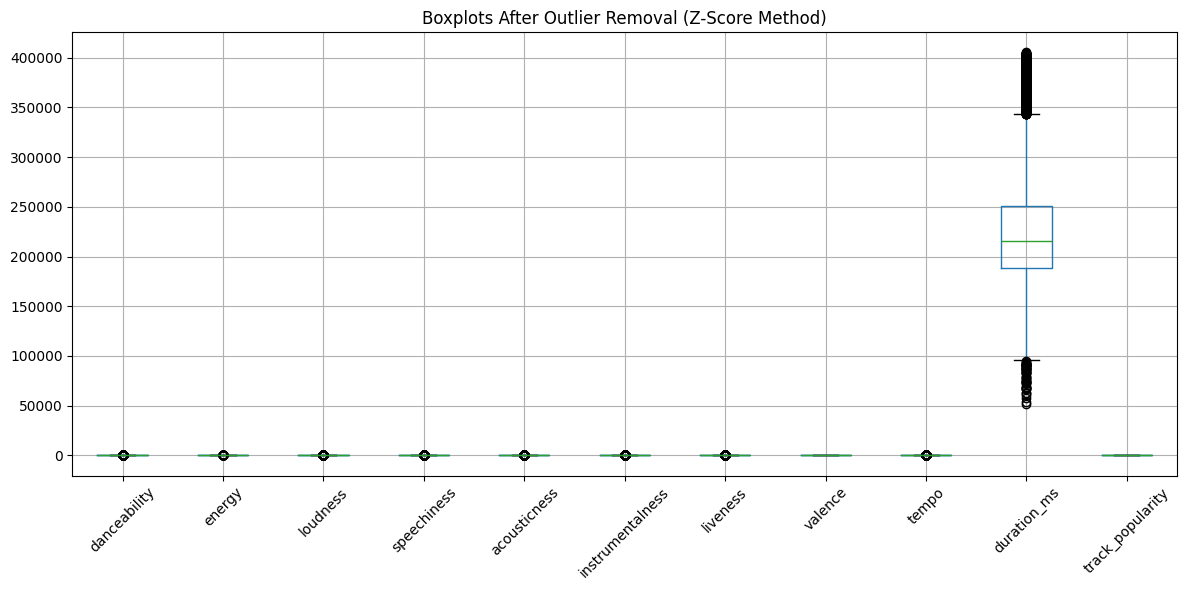

In [221]:
# Boxplots before outlier removal
plt.figure(figsize=(12, 6))
df_numeric.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots Before Outlier Removal (Z-Score Method)")
plt.tight_layout()
plt.show()

# Count outliers using the Z-score method
z_scores = np.abs(zscore(df_numeric, nan_policy="omit"))

print("\nOutlier Counts by Column:")
for i, col in enumerate(df_numeric.columns):
    count = (z_scores[:, i] > 3).sum()
    print(f"{col}: {count} outliers")

# Remove rows with at least one Z-score above 3
z_mask = (z_scores > 3).any(axis=1)

df_clean_numeric = df_numeric[~z_mask]
df_clean = df.loc[~z_mask].copy()

print("\nOriginal shape:", df_numeric.shape)
print("After outlier removal:", df_clean_numeric.shape)

# Boxplots after outlier removal
plt.figure(figsize=(12, 6))
df_clean_numeric.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots After Outlier Removal (Z-Score Method)")
plt.tight_layout()
plt.show()

# Standardize numeric features


In [222]:
# Scale only numeric cleaned features before K-Means
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean_numeric)

# Determine optimal number of clusters

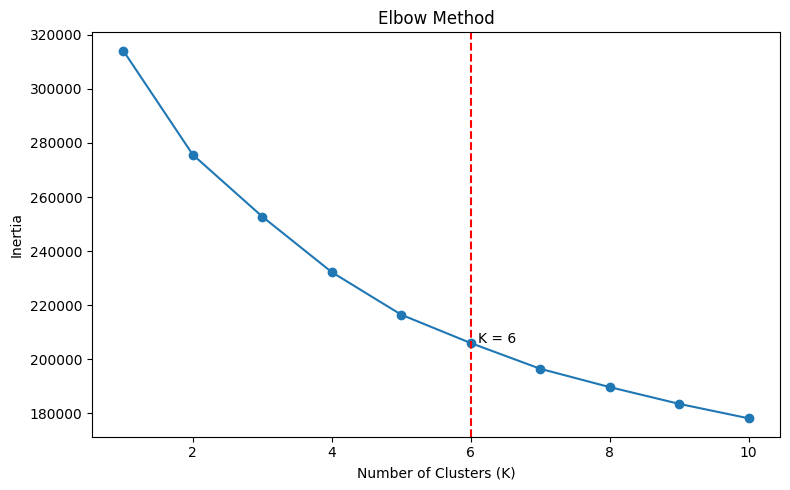

In [223]:
# Use the elbow method on the cleaned and scaled dataset
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# K = 6 was selected based on the elbow method where inertia begins to level off,
# indicating diminishing returns in cluster improvement beyond this point.
optimal_k = 6

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.axvline(x=optimal_k, linestyle="--", color="red")
plt.text(optimal_k + 0.1, inertia[optimal_k - 1], f"K = {optimal_k}")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

# Apply the k-means model

In [224]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clean["Cluster"] = kmeans.fit_predict(scaled_data)

print(df_clean.head())

                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                                    track_album_name track_album_release_date  \
0  I Don't Care (with Justin Bieber) [Loud Luxu

# Evaluate clustering with silhouette scores

In [225]:
sil = silhouette_score(scaled_data, df_clean['Cluster'])
print(f"Silhouette Score: {sil:.4f}")
print("\nSilhouette Interpretation:")
print("The silhouette score measures how well-separated the clusters are, with values closer to 1 indicating stronger separation.")

if sil >= 0.5:
    print("This indicates strong cluster separation.")
elif sil >= 0.2:
    print("This indicates moderate cluster separation.")
else:
    print("This indicates weak cluster separation, suggesting overlapping clusters.")

Silhouette Score: 0.1124

Silhouette Interpretation:
The silhouette score measures how well-separated the clusters are, with values closer to 1 indicating stronger separation.
This indicates weak cluster separation, suggesting overlapping clusters.


# Visualize the clusters

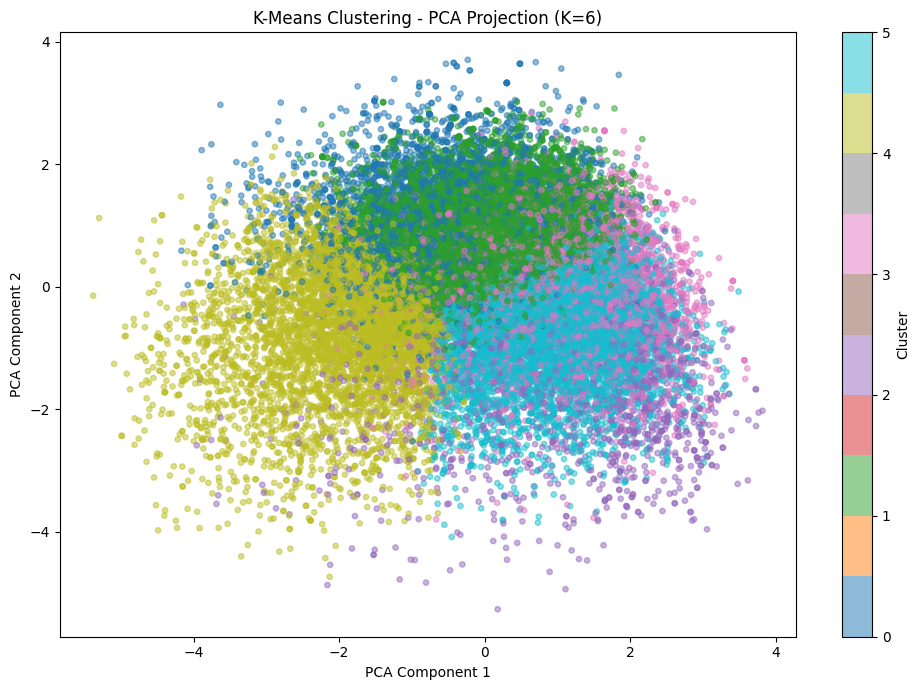

In [226]:
# PCA with 2 components was used to reduce the dataset to two dimensions for visualization, allowing cluster structure to be displayed while preserving the majority of the variance in the data.
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_data)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=df_clean["Cluster"],
    cmap="tab10",
    alpha=0.5,
    s=15
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clustering - PCA Projection (K={optimal_k})")
plt.tight_layout()
plt.show()

# Interpret cluster profiles

In [227]:
# Interpret cluster profiles using the same features used for K-Means
feature_cols = df_clean_numeric.columns

cluster_profiles = df_clean.groupby("Cluster")[feature_cols].mean()

print("Cluster Profiles:")
print(cluster_profiles.round(2))

print("\nCluster Sizes:")
print(df_clean["Cluster"].value_counts().sort_index())

print("\nInterpretation:")
print("Each cluster represents a distinct music profile based on audio features.")

print("\nCluster 0 - Speechy Dance Tracks: High danceability (0.74) and elevated speechiness (0.28) suggest rap or hip-hop influenced tracks. Moderate energy and popularity (44.6).")
print("Cluster 1 - Happy Mainstream Pop: Highest popularity (49.38), high danceability (0.74), high valence (0.69), and low speechiness (0.07). These are upbeat, feel-good mainstream hits.")
print("Cluster 2 - Instrumental Electronic: Extremely high instrumentalness (0.55) with high energy (0.79) and low valence (0.41). These are likely instrumental or electronic tracks with minimal vocals and lower popularity (30.69).")
print("Cluster 3 - Live Performance Tracks: Highest liveness score (0.39) with high energy (0.80), suggesting these tracks were recorded live or have strong live performance characteristics.")
print("Cluster 4 - Soft Acoustic Songs: Lowest energy (0.49), highest acousticness (0.37), and quietest loudness (-9.43 dB). These are mellow, acoustic-style tracks such as folk, singer-songwriter, or ballads.")
print("Cluster 5 - High-Energy Dark Tracks: Highest tempo (132.39 BPM) and energy (0.79) but lowest valence (0.37), meaning these are fast and loud but emotionally negative or tense, likely hard rock or aggressive electronic.")

print("\nConclusion:")
print("K-Means clustering successfully grouped songs into 6 distinct clusters based on their audio characteristics.")
print("These clusters reveal meaningful patterns across music styles including rap, pop, instrumental, live, acoustic, and high-energy tracks.")

print("\nReal-World Use Cases:")
print("This approach can be used for playlist generation, music recommendation systems,")
print("customer segmentation, and personalized content delivery in streaming platforms.")

Cluster Profiles:
         danceability  energy  loudness  speechiness  acousticness  \
Cluster                                                              
0                0.74    0.67     -6.68         0.28          0.18   
1                0.74    0.74     -5.71         0.07          0.14   
2                0.65    0.79     -6.58         0.08          0.08   
3                0.64    0.80     -5.49         0.09          0.09   
4                0.64    0.49     -9.43         0.07          0.37   
5                0.54    0.79     -5.28         0.07          0.06   

         instrumentalness  liveness  valence   tempo  duration_ms  \
Cluster                                                             
0                    0.01      0.16     0.55  120.08    216742.10   
1                    0.01      0.12     0.69  114.59    214714.52   
2                    0.55      0.18     0.41  124.51    232218.91   
3                    0.02      0.39     0.54  121.61    219391.20   
4      